In [1]:
import wget
import os
import healpy as hp
import math
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.odr import Model, Data, ODR
from scipy.optimize import curve_fit
from astropy.io import fits
from reproject import reproject_to_healpix

from astropy import units as u, constants as const
from scipy import integrate 

def beamsolidangle(fwhm):
    """
    Given a FWHM resolution `fwhm`,
    it computes the solid angle subtended by a Gaussian-axisymmetric beam
     in steradians by performing :

    .. math::
        \Delta \Omega = \int d \phi  d\theta  \sin(theta) \e^{-\theta^2/(2\sigma_b^2)}
    """

    sigma = (fwhm / 2 / np.sqrt(2 * np.log(2))).to(u.rad).value
    
    x = np.linspace(0, 4 * sigma, 2048)
    Gaussian = lambda theta: np.exp(-((theta / (np.sqrt(2) * sigma)) ** 2))
    integrand = lambda theta: 2 * np.pi * np.sin(theta) * Gaussian(theta)
    Solid_angle = (
        integrate.quad(integrand, 0, x.max(), limit=1000, epsrel=1.0e-5)[0] * u.sr
    )
    return Solid_angle

def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )

def planckcorr(freq_ghz):
    """ Takes in frequency in GHZ and produces factor to be applied to temp """

    freq = freq_ghz * 10.**9.
    CST = {"kbolt": 1.3806488e-23, "light": 2.99792458e8, "plancks": 6.626e-34, "cmb_temp": 2.725}
    factor = CST["plancks"] * freq / (CST["kbolt"] * CST["cmb_temp"])
    correction = (np.exp(factor)-1.)**2. / (factor**2. * np.exp(factor))

    return correction



<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_11801/1019984190.py:18: SyntaxWarning: invalid escape sequence '\D'
  """


## Disclaimer 

applying few changes on Mel code for fine reso maps. 
- downgrading maps at `nside=256`
- smoothing maps at `fwhm=1.2 deg`
this is mainly because , there ain't no need to run with `nside=512` (6.9 arcmin), the pixel reso at 256   (13.7 arcmin ) is enough for degree reso . also want to push as much as i could the resolution of maps towards the degree scale. 

Offsets estimated for Q11 in any case are in any case bad. see plot below. 


In [2]:
folder_path = "../GLEAM"
Path(folder_path).mkdir(parents=True, exist_ok=True)

In [3]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]

def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval


def remove_off(map, hasmap, maperr, haserr):
    nside_superpix=16
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    try : 
        ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
        pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

        if pixs[nan1] [0]==0 :
            print("Southern Survey ") 
            super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
        else: 
            print("Northern survey ")
            super_pixs=  np.arange(pix1) 
    except IndexError: 
        print('Fullsky survey')
        super_pixs=  np.arange(hp.nside2npix(nside_superpix )) 
    offsets = np.zeros_like(super_pixs)*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)  
   

    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if ~np.isnan(np.nanmean(map[patch].value)):
                print(np.corrcoef(hasmap[patch].value, map[patch].value)[0,1])
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.15:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 
            
    offmap[super_pixs] = offsets 

    #avec = np.nanmean( offsets ) *map.unit 
    avec = np.nanmedian( offsets ) *map.unit 
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 
 


https://lambda.gsfc.nasa.gov/product/wmap/dr5/ 

https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_get.html



https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/deconv/images/wmap_band_deconv_imap_r9_9yr_K_v5.fits

https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/haslam408_ds_Remazeilles2014.fits

https://lda10g.alliance.unm.edu/LWA1LowFrequencySkySurvey/
https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/healpix-all-sky-rav-wsclean-map-50.fits

https://lambda.gsfc.nasa.gov/product/foreground/fg_rhodes_hart_info.html


In [4]:
freqs=np.array([
    88, 118, 154, 200.5
    ]) 
maps={}
mapserr={}
offerr={}

cwd = Path.cwd() 

for j,fr in enumerate(freqs) :
    if fr == 88:
        fstring=(f"GLEAM_072_103_1_4096.fits")
    elif fr == 118:
        fstring=(f"GLEAM_103_134_1_4096.fits")
    elif fr == 154:
        fstring=(f"GLEAM_139_170_1_4096.fits")
    elif fr == 200.5:
        fstring=(f"GLEAM_170_231_1_4096.fits")
    
    try : 
        print(f"reading {fstring} ")
        maps[fr],_=  hp.read_map(f"../GLEAM/{fstring}" ,h=True  )
    except FileNotFoundError: 
        filename = wget.download( f"http://cade.irap.omp.eu/documents/Ancillary/GLEAM/{fstring}", out ="../ovro_lwa_data")
        maps[fr] =  hp.read_map(f"../GLEAM/{fstring}"  )

    maps[fr] = (maps[fr] *u.Jy/beamsolidangle(2*u.arcmin)  ).to(u.K, 
                                                               equivalencies=u.brightness_temperature(fr*u.MHz))
    zeros = np.where(maps[fr].value  < - 9000)
    maps[fr][zeros] = np.nan
    zeros2 = hp.query_strip(4096, np.radians(77.), np.radians(103.0))
    maps[fr][zeros2] = np.nan
    mapserr[fr] = 0.05
    offerr[fr] = 0.0

fstring="STOCKERT+VILLA-ELISA_1420MHz_1_256.fits"
try :
        
    print(f"reading {fstring} ")

    maps[1400],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/reich_reich/{fstring}", out ="../lwa_data")
    maps[1400]=  hp.read_map(f"../lwa_data/{fstring}"  )

maps[1400] = maps[1400] * 1.55
maps[1400]= (maps[1400]*u.mK   ).to(maps[88].unit) 
offerr[1400] = 0.0
mapserr[1400] = 0.10 # 10 per cent for 1400 calibration


fstring="staps.i.E.smooth.K.fits"
target_header = fits.Header.fromstring("""
NAXIS   =                    2
NAXIS1  =                  7201
NAXIS2  =                  1821
CTYPE1  = 'RA---CAR'
CRPIX1  =                3601.0
CRVAL1  =                0.0
CDELT1  =               -0.05
CUNIT1  = 'deg     '
CTYPE2  = 'DEC--CAR'
CRPIX2  =                1801.0
CRVAL2  =                  0.0
CDELT2  =                0.05
CUNIT2  = 'deg     '
COORDSYS= 'icrs    '
""", sep='\n')
try :
        
    print(f"reading {fstring} ")

    hdul = fits.open(f"../southern_data/staps.i.E.smooth.K.fits" ) 
except FileNotFoundError: 
    filename = wget.download( f"https://cdsarc.cds.unistra.fr/ftp/J/A+A/694/A169/fits/{fstring}", out ="../southern_data")
    hdul = fits.open(f"../southern_data/staps.i.E.smooth.K.fits" )

header = hdul[0].header
data = hdul[0].data
maps[1324], _ = reproject_to_healpix((data[0,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1349], _ = reproject_to_healpix((data[25,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1374], _ = reproject_to_healpix((data[50,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1456], _ = reproject_to_healpix((data[125,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1524], _ = reproject_to_healpix((data[163,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1609], _ = reproject_to_healpix((data[164,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1628], _ = reproject_to_healpix((data[174,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1700], _ = reproject_to_healpix((data[232,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1749], _ = reproject_to_healpix((data[279,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1770], _ = reproject_to_healpix((data[-1,:,:], target_header), 'galactic', nside=512, nested=False)

maps[1324]= (maps[1324]*u.K   ).to(maps[88].unit) 
offerr[1324] = 0.0
mapserr[1324] = 0.1 

maps[1349]= (maps[1349]*u.K   ).to(maps[88].unit) 
offerr[1349] = 0.0
mapserr[1349] = 0.1 

maps[1374]= (maps[1374]*u.K   ).to(maps[88].unit) 
offerr[1374] = 0.0
mapserr[1374] = 0.1 

maps[1456]= (maps[1456]*u.K   ).to(maps[88].unit) 
offerr[1456] = 0.0
mapserr[1456] = 0.1 

maps[1524]= (maps[1524]*u.K   ).to(maps[88].unit) 
offerr[1524] = 0.0
mapserr[1524] = 0.1

maps[1609]= (maps[1609]*u.K   ).to(maps[88].unit) 
offerr[1609] = 0.0
mapserr[1609] = 0.1

maps[1628]= (maps[1628]*u.K   ).to(maps[88].unit) 
offerr[1628] = 0.0
mapserr[1628] = 0.1

maps[1700]= (maps[1700]*u.K   ).to(maps[88].unit) 
offerr[1700] = 0.0
mapserr[1700] = 0.1

maps[1749]= (maps[1749]*u.K   ).to(maps[88].unit) 
offerr[1749] = 0.0
mapserr[1749] = 0.1

maps[1770]= (maps[1770]*u.K   ).to(maps[88].unit) 
offerr[1770] = 0.0
mapserr[1770] = 0.1

fstring="lambda_23de_hea.fits"
try :
    print(f"reading {fstring} ")
    maps[2326]=  hp.read_map(filename=f"../southern_data/{fstring}")  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/rhodes_2326/{fstring}" , out ="../southern_data")
    maps[2326]=  hp.read_map(f"../southern_data/{fstring}")  
maps[2326] = rotate_map(maps[2326], 'C', 'G')
zeros = maps[2326]< 0.027 
maps[2326][zeros] = np.nan
maps[2326]= (maps[2326]*u.K   ).to(maps[88].unit) 
offerr[2326] = 0.0
mapserr[2326] = 0.05 # 5 per cent for 2300 calibration

reading GLEAM_072_103_1_4096.fits 
reading GLEAM_103_134_1_4096.fits 
reading GLEAM_139_170_1_4096.fits 
reading GLEAM_170_231_1_4096.fits 
reading STOCKERT+VILLA-ELISA_1420MHz_1_256.fits 
reading staps.i.E.smooth.K.fits 
reading lambda_23de_hea.fits 


smoothing and downgrading maps 


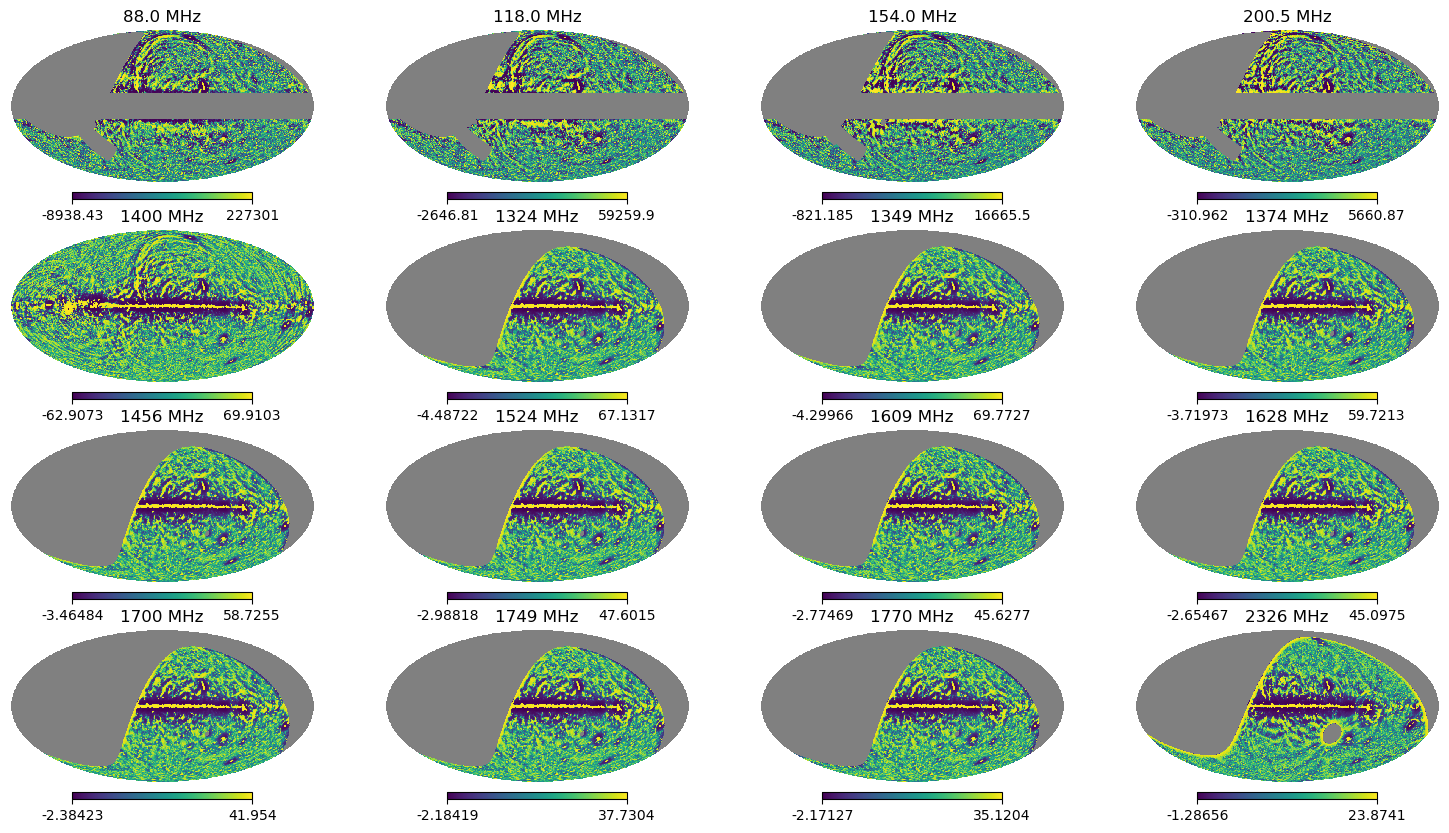

In [5]:
nside = 256 
npix= hp.nside2npix(nside)
freqs  =  np.array([  k for k in maps.keys()  ])  

fwhms = {88: 2.0*u.arcmin, 
         118: 2.0 *u.arcmin , 
        154: 2.0*u.arcmin,
        200.5: 2.0*u.arcmin,
       1324: 20.0*u.arcmin, 
       1349: 20.0*u.arcmin,
       1374: 20.0*u.arcmin,  
       1400: 35.4*u.arcmin,
       1456: 20.0*u.arcmin, 
       1524: 20.*u.arcmin,
       1600: 20.*u.arcmin,
       1609: 20.*u.arcmin,
       1628: 20.*u.arcmin,
       1700: 20.*u.arcmin,
       1749: 20.*u.arcmin,
       1770: 20.*u.arcmin,
       2326: 20.0 *u.arcmin, 
        }

fwhmax = 36.*u.arcmin
print("smoothing and downgrading maps ")

for k  in freqs:

    nans= np.ma.masked_invalid(maps[k] ).mask
    maps[k] [nans] =hp.UNSEEN*u.K 
        
    maps[k] = hp.ud_grade(maps[k].value , nside_out=nside)*maps[k].unit
    nans= np.where(maps[k].value == hp.UNSEEN)[0]

    # for gleam we need to add in the scales that thhose maps are missing (over 5 degrees using previous fitting)
    maxres = 5.0
    mapmax = hp.smoothing(maps[k] , fwhm=pl.sqrt((maxres*u.deg)**2 - fwhms[k] **2 ).to(u.rad).value)
    maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value)
    maps[k] = maps[k] - mapmax
    maps[k] = maps[k]*u.K 
    maps[k][nans] = np.nan

pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview( m .value   , norm='hist', title=f'{fr} MHz'  , sub=(5,4,1+j) , notext=True)
    
    j+=1

pl.show()

## Offset removal 

In [6]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

def process_frequency(k):

    maps[k] = maps[k]
    offset = 0.0 
    offerr[k] = 0.0
    off_map = np.zeros_like(maps[k].value)


    return k, offset, offerr[k], off_map 

# Parallelize the loop
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_frequency, freqs[freqs != 408]), total=len(freqs[freqs != 408])))

# Process results
for k, offset, error_offset,_  in results:
    print(f" {k} MHz data estimated offset: {offset:.4f} ± {error_offset:.4f}")

100%|██████████| 16/16 [00:00<00:00, 86369.19it/s]

 88.0 MHz data estimated offset: 0.0000 ± 0.0000
 118.0 MHz data estimated offset: 0.0000 ± 0.0000
 154.0 MHz data estimated offset: 0.0000 ± 0.0000
 200.5 MHz data estimated offset: 0.0000 ± 0.0000
 1400.0 MHz data estimated offset: 0.0000 ± 0.0000
 1324.0 MHz data estimated offset: 0.0000 ± 0.0000
 1349.0 MHz data estimated offset: 0.0000 ± 0.0000
 1374.0 MHz data estimated offset: 0.0000 ± 0.0000
 1456.0 MHz data estimated offset: 0.0000 ± 0.0000
 1524.0 MHz data estimated offset: 0.0000 ± 0.0000
 1609.0 MHz data estimated offset: 0.0000 ± 0.0000
 1628.0 MHz data estimated offset: 0.0000 ± 0.0000
 1700.0 MHz data estimated offset: 0.0000 ± 0.0000
 1749.0 MHz data estimated offset: 0.0000 ± 0.0000
 1770.0 MHz data estimated offset: 0.0000 ± 0.0000
 2326.0 MHz data estimated offset: 0.0000 ± 0.0000


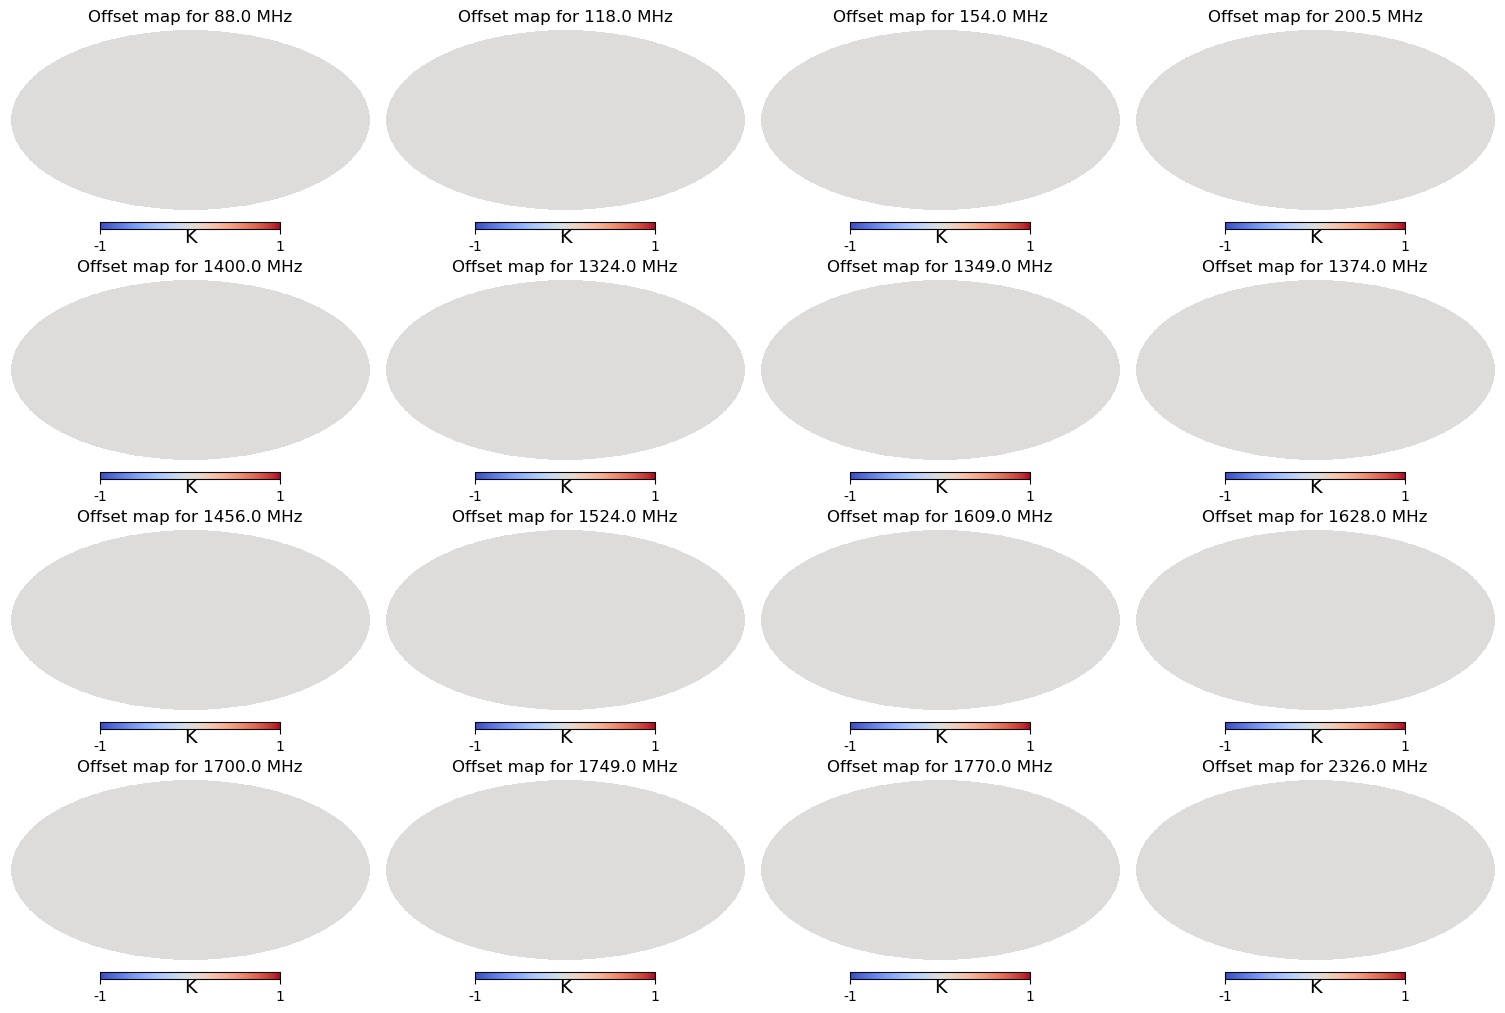

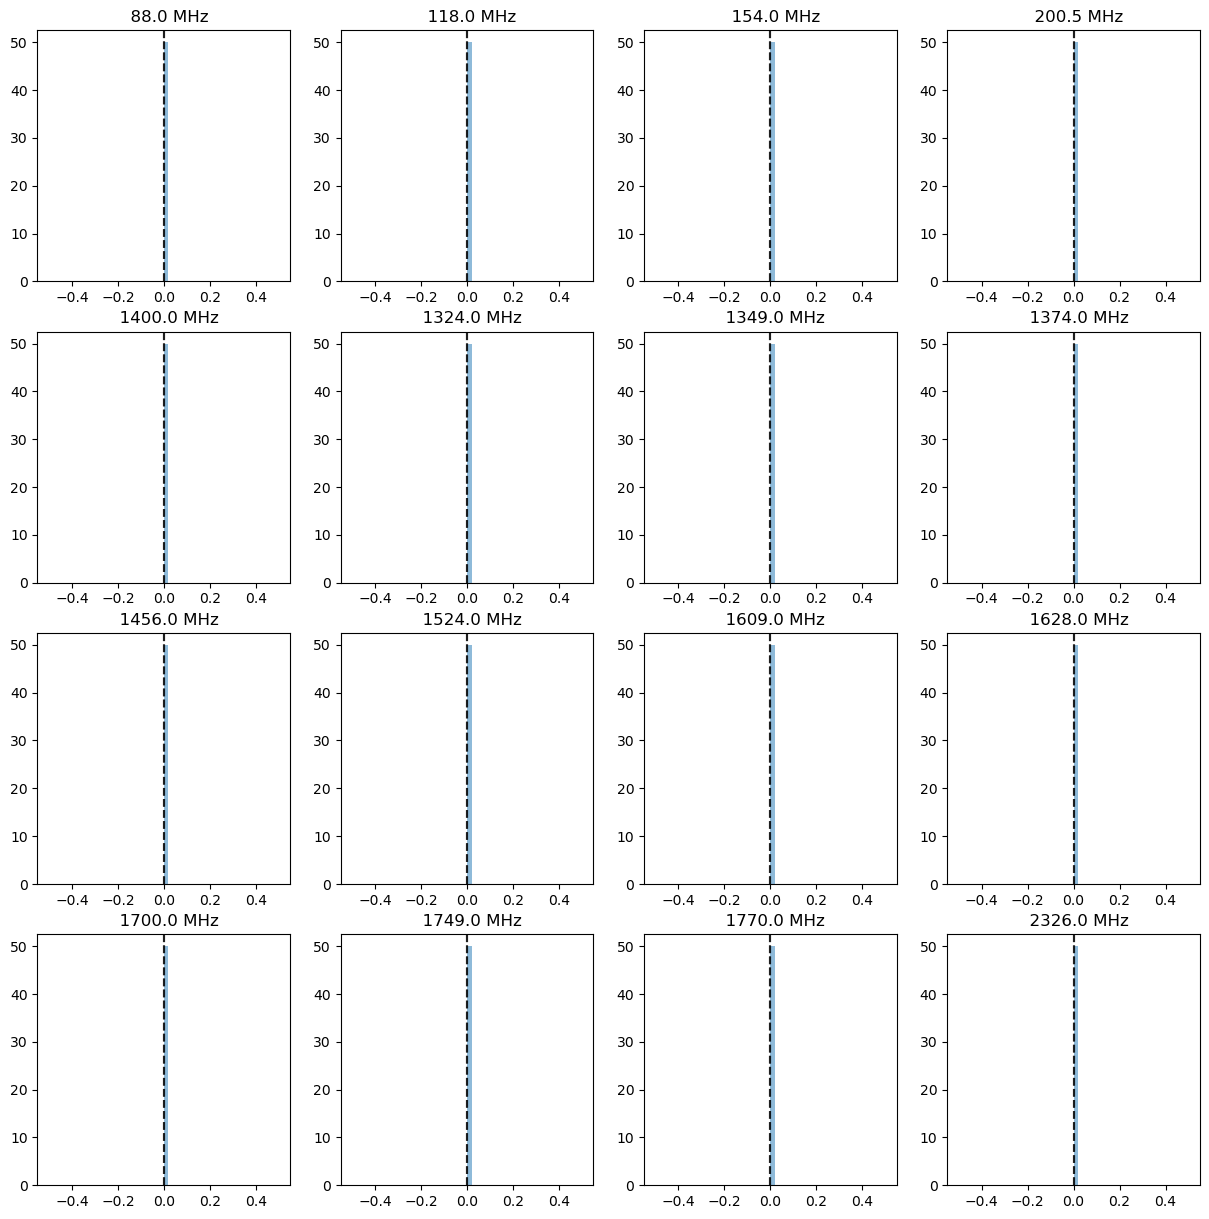

In [7]:
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

j=0
pl.figure(figsize=(15, 10))

for k, offset, error_offset, offset_map  in results:
    hp.mollview(offset_map, title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm',
                sub=(4,4,j+1))
    j+=1

offset_file = open(output_dir+'/offset_finest_south.txt', 'w')

pl.figure(figsize=(15, 15))
j=0
for k, offset, error_offset, offset_map  in results:
    try:
        offset_file.write("%f %f % f\n" %(k, offset.value, error_offset))
    except:
        offset_file.write("%f %f % f\n" %(k, offset, error_offset))
    pl.subplot(4, 4, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(offset_map ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    try:
        pl.axvline ( offset.value,ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset.value -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset.value +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    except:
        pl.axvline ( offset, ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1

offset_file.close()

/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_11801/2348292699.py:5: RuntimeWarning: invalid value encountered in log
  hp.mollview( np.log(m.value ),  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True)


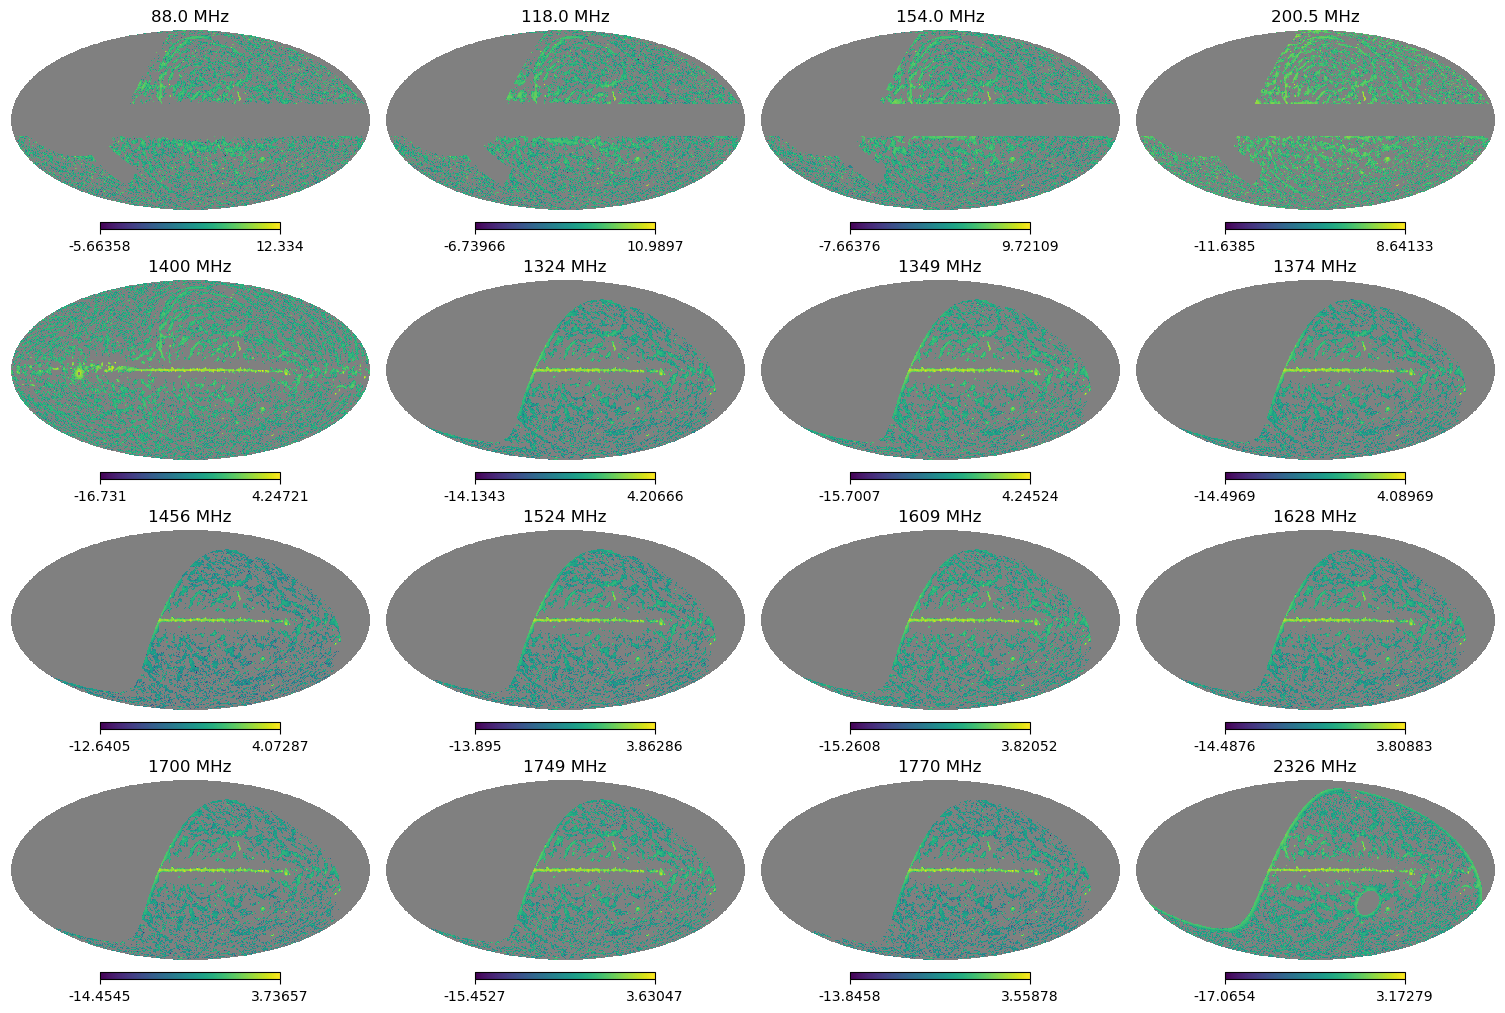

In [8]:
pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview( np.log(m.value ),  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True)
    
    j+=1


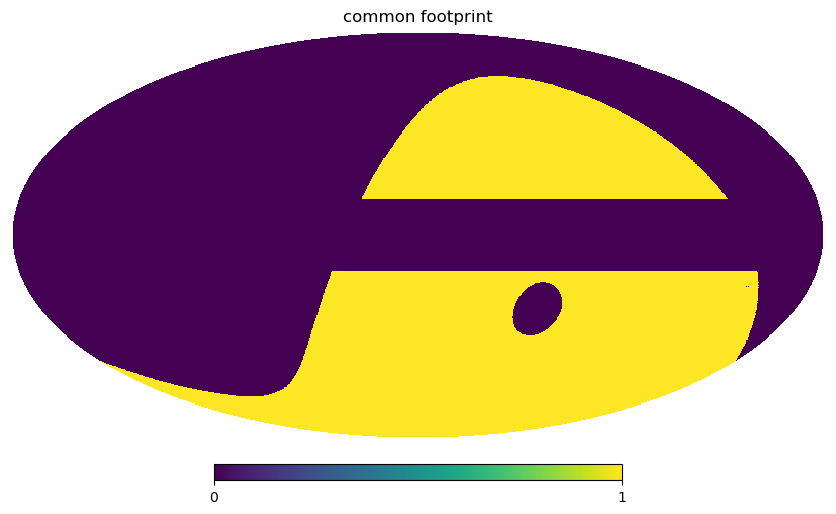

In [19]:
jonas_nans = np.ma.masked_invalid(maps[2326]).mask
stap_mask=  np.ma.masked_invalid(maps[1770]).mask
g_mask=  np.ma.masked_invalid(maps[88]).mask

common_footprint0 =  np.logical_and(~jonas_nans , ~stap_mask)  
common_footprint =  np.logical_and(common_footprint0 , ~g_mask)  
hp.mollview(common_footprint, title='common footprint' ) 


In [10]:
fstring="COM_CompMap_freefree-commander_0256_R2.00.fits"
try :
    print(f"reading {fstring} ")
    tmp=  hp.read_map(filename=f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )  
except FileNotFoundError: 
    filename = wget.download( f"http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_freefree-commander_0256_R2.00.fits" , out ="../lwa_data")
    tmp=  hp.read_map(f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )
 
planck_em = tmp[0]* u.cm**-6 *u.pc
planck_te = tmp [1]*u.K 

fstring = "EM_mean_std.fits"
try :
    print(f"reading {fstring} ")
    hust=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://zenodo.org/records/10523170/files/EM_mean_std.fits" , out ="../lwa_data")
    hust =  hp.read_map(f"../lwa_data/{fstring}"    )
hust *= u.cm**-6 *u.pc

reading COM_CompMap_freefree-commander_0256_R2.00.fits 
reading EM_mean_std.fits 


In [ ]:
Tff = lambda Te , nu,EM  : Te * (1.0 - np.exp(-tauff(Te,nu, EM ))) 
tauff = lambda Te,nu , EM : 0.05468 *   (Te.value )**-1.5 * (nu.value )**-2 *EM.value   *gff (Te,nu) 
Zi =1 
gff =lambda Te ,nu :  np.log (np.exp(1.0) +np.exp (5.960 -np.sqrt(3)/np.pi *np.log (Zi *nu.to(u.GHz).value *(Te/(1e4*u.K)  )**-1.5  )) )  
free ={} 
for fr in maps.keys() : 
    tmp = Tff(Te=planck_te, nu=(fr*u.MHz).to(u.GHz), EM=hust  )
    tmp = hp.ud_grade(tmp, nside_out=nside)
    tmp5 = hp.smoothing(tmp, fwhm=pl.sqrt(5.0*u.deg**2 -  1.*u.deg **2 ).to(u.rad).value)
    print('ff map still at 1 degree')
    tmp_new = tmp
    tmp = tmp_new - tmp5 #take off scales over 5 degrees

    free[fr]= (tmp)* (maps[88].unit)  

ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree
ff map still at 1 degree


48.90422764006148 -2.2730649


/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_11801/3996175799.py:16: RuntimeWarning: invalid value encountered in log10
  hp.mollview(  pl.log10(m .value)   ,  title=f'{fr} MHz'  , sub=(5,4,1+j) , notext=True)


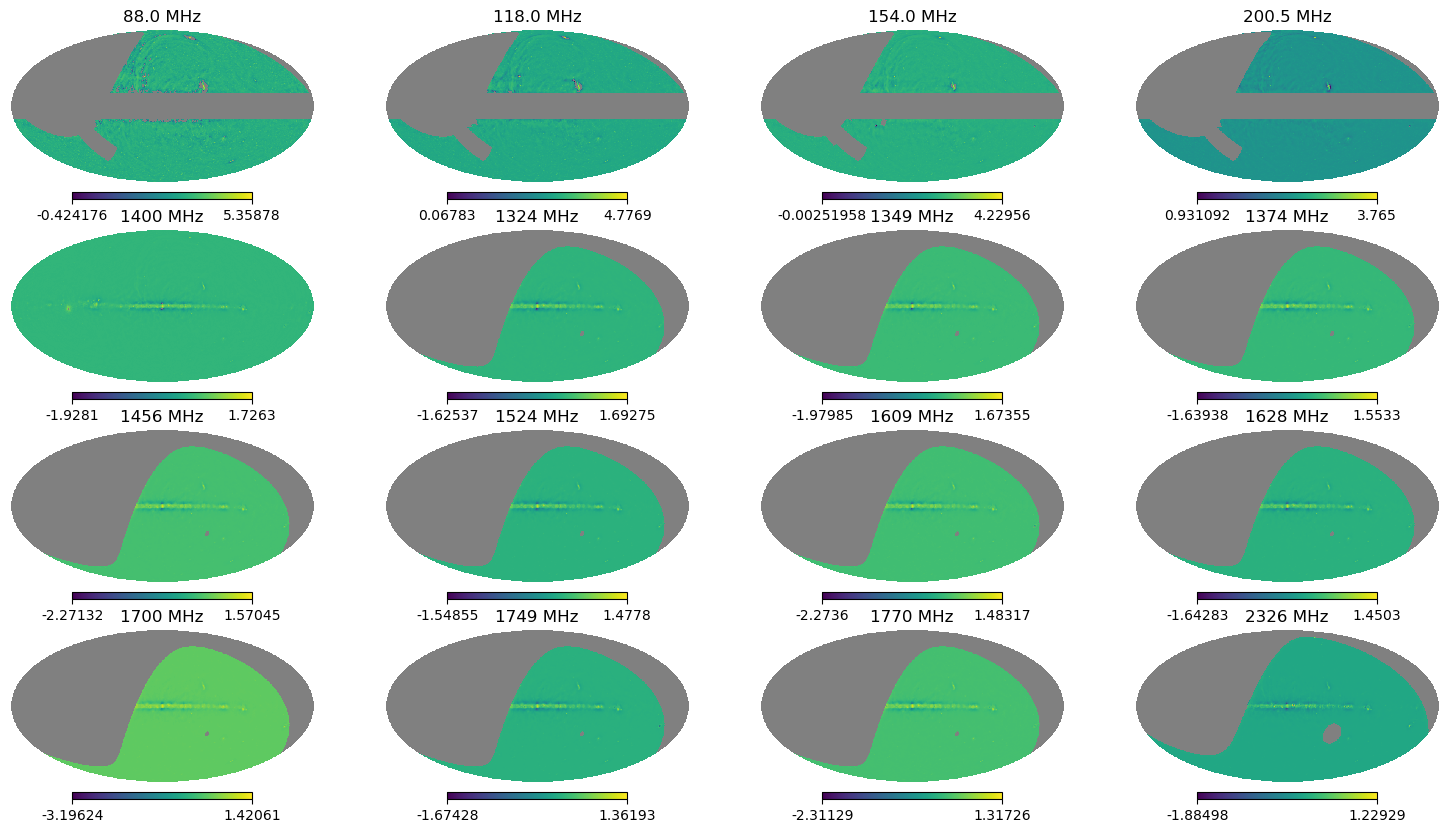

In [12]:
#need to add new offsets to the maps so that we have no negative temps (beta = log((p2/p1) / (v2/v1)) = log((p2 + 1.1*p2 / p1 + 1.1 * p1) / (v2/v1)) )
mean_gleam = np.nanmean(maps[88].value)
has = hp.read_map(f"../lwa_data/haslam408_ds_Remazeilles2014.fits")
has_mean_value = np.mean(has - 8.9)  
added_mean_value = has_mean_value - mean_gleam
coarse_beta = hp.read_map(f"{output_dir}/bfit_maps_south_11.fits")
mean_beta = np.nanmean(coarse_beta)
print(added_mean_value, mean_beta)
for k  in freqs:
    maps[k] = (maps[k].value - free[k].value) * maps[k].unit 
    maps[k] = (maps[k].value + added_mean_value * (k/408.0)**(mean_beta)) * maps[k].unit 

pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
    hp.mollview(  pl.log10(m .value)   ,  title=f'{fr} MHz'  , sub=(5,4,1+j) , notext=True)
    
    j+=1

pl.show() 

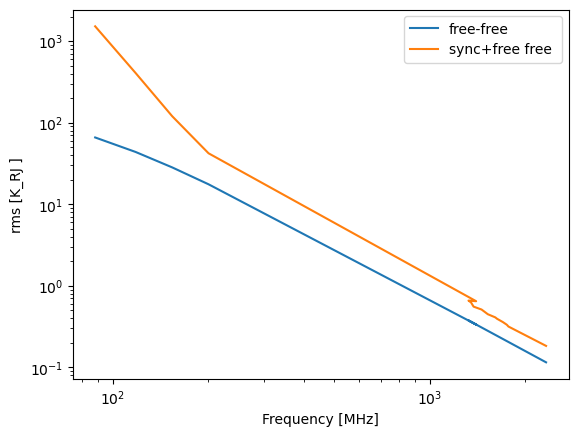

In [20]:
rmsf =np.array( [ np.nanstd(f .value)    for f in free.values() ] ) 
rmsm = np.array( [ np.nanstd(m .value)    for m in maps.values() ] ) 
pl.loglog( freqs, rmsf  ,label='free-free' ,)
pl.loglog( freqs, rmsm  , label='sync+free free ', )

pl.legend()
pl.xlabel('Frequency [MHz]')
pl.ylabel('rms [K_RJ ]')  
pl.show() 


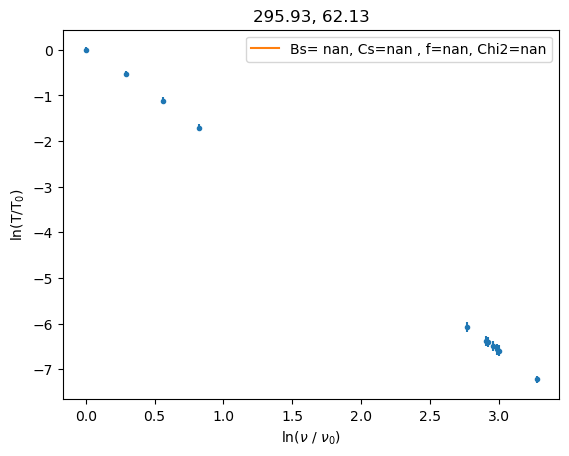

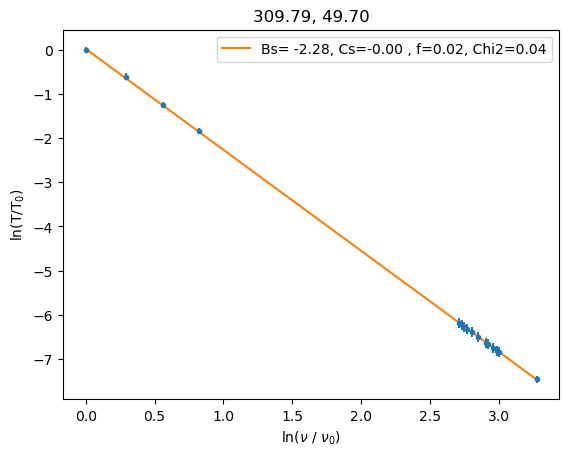

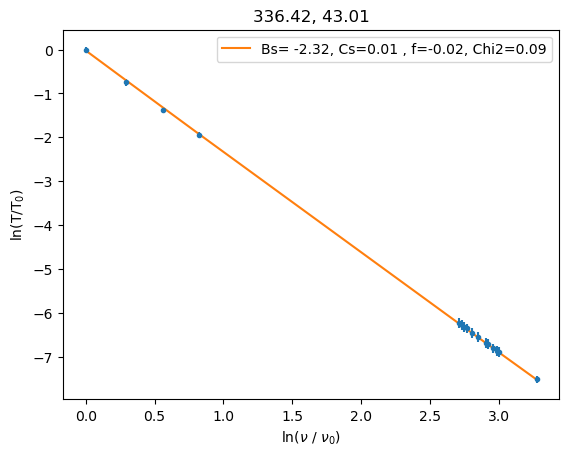

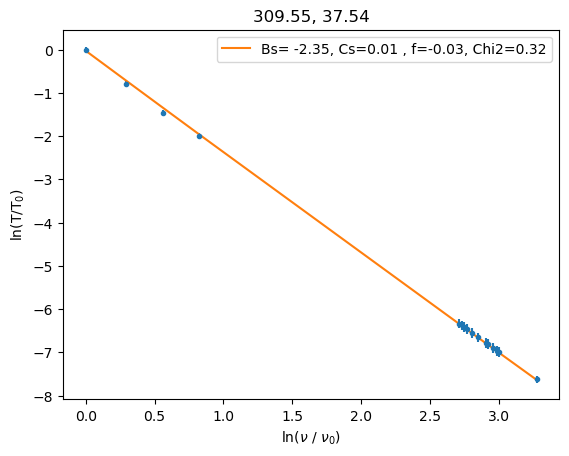

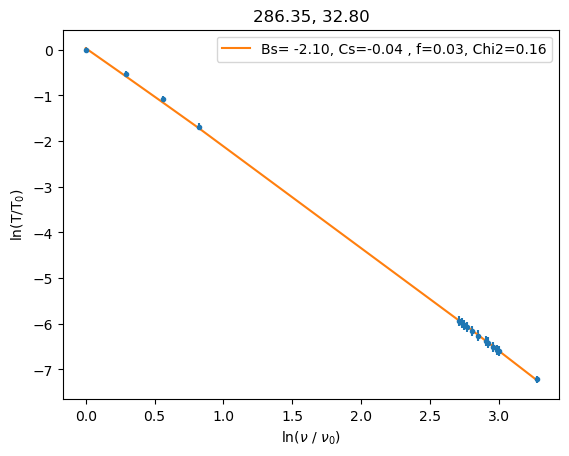

In [14]:
oldbs = hp.read_map("../outputs/bfit_maps_south_fine.fits", field=0)
oldcs = hp.read_map("../outputs/bfit_maps_south_fine.fits", field=1)
olda = hp.read_map("../outputs/bfit_maps_south_fine.fits", field=2)

def fitting_beta_curvature(X, beta, cs, const):
    return beta * X + cs * X * X + const

def process_pixel(ipix, return_errors=False):
    ifreq = np.argmin(np.abs(freqs - 88.))
    pixvals = np.array([(m[ipix].value) for k, m in maps.items()])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq])
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    p0 = np.array([-3, -0.1, 1])
    ret = np.full(p0.size + 2, np.nan)
    ret[0] = ipix
    errs = np.full(p0.size, np.nan)
    pcov = np.zeros((3, 3)) + np.nan
    if nans.sum():
        return (ret, errs) 
    try:
        p0 = np.array([oldbs[ipix], 
                   oldcs[ipix],
                  olda[ipix] ,
                    ])
        lowb = oldbs[ipix] - 0.05 * abs(oldbs[ipix])
        hib = oldbs[ipix] + 0.05 * abs(oldbs[ipix])
        lowc = oldcs[ipix] - 0.05 *abs(oldcs[ipix])
        hic = oldcs[ipix] + 0.05 * abs(oldcs[ipix])
        lowa = olda[ipix] - 0.05 * abs(olda[ipix])
        hia = olda[ipix] + 0.05 * abs(olda[ipix])
        popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat, 
                               sigma=logyerr,  p0=p0, bounds = ((lowb, lowc, lowa), (hib, hic, hia))) 
        ret[-1] = np.sum(((ydat - fitting_beta_curvature(xdat, *popt)) / logyerr) ** 2)/(xdat.size -p0.size   )
        ret[1:-1] = popt
        errs = np.sqrt(np.diag(pcov))
        return ret, errs 
    except Exception:
        return ret, errs 

pixel_select = np.arange(npix)[common_footprint]
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)

error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)

ifreq = np.argmin(np.abs(freqs - 88.))
jj = 0
for ipix in pixel_select[::1000]:
    # Use return_errors=True for error estimation, False for covariance
    fitted_params, error_params = process_pixel(ipix, return_errors=True)
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] = fitted_params[3]
    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = error_params[0]
    error_csmap[ipix] = error_params[1]
    error_fmap[ipix] = error_params[2]
    pixvals = np.array([ (m[ipix].value - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    if jj%10==0:
        pl.figure() 
        lon,lat =hp.pix2ang(ipix=ipix, nside=nside,  lonlat=True) 
        pl.title( f"{lon:.2f}, {lat:.2f}" )
        pl.errorbar ( xdat ,  ydat ,
                     yerr= logyerr  ,
                        fmt='.' )
         
        pl.plot(xdat,  fitting_beta_curvature( xdat , *fitted_params[1:-1] ),  
                label =f'Bs= {fitted_params[1]:.2f}, Cs={fitted_params[2]:.2f} , f={fitted_params[3]:.2f}, Chi2={fitted_params[-1]:.2f}' ) 
                #, Bf={fitted_params[4]:.2f}, 

        #pl.semilogx() 
        #pl.loglog() 
        pl.legend()
        pl.xlabel(r"ln($\nu$ / $\nu_{0}$)")
        pl.ylabel(r"ln(T/T$_{0}$)") 
    jj+=1 
    if jj== 50: break

In [15]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

    
# Initialize shared arrays
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)
error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)



# Use ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_pixel, pixel_select), total=len(pixel_select)))

for fitted_params, errs  in results:
    ipix = int(fitted_params[0])  # Ensure ipix is an integer
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] =   fitted_params[3]
    #betafmap[ipix] = fitted_params[4]

    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = errs[0]
    error_csmap[ipix] = errs[1]
    error_fmap[ipix] = errs[2]

    


 18%|█▊        | 52741/296192 [01:14<05:39, 717.78it/s]/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_11801/1012866198.py:12: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])
 21%|██        | 61227/296192 [01:26<05:33, 704.85it/s]/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_11801/1012866198.py:43: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat,
100%|██████████| 296192/296192 [07:12<00:00, 684.34it/s] 


/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_11801/2556839328.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


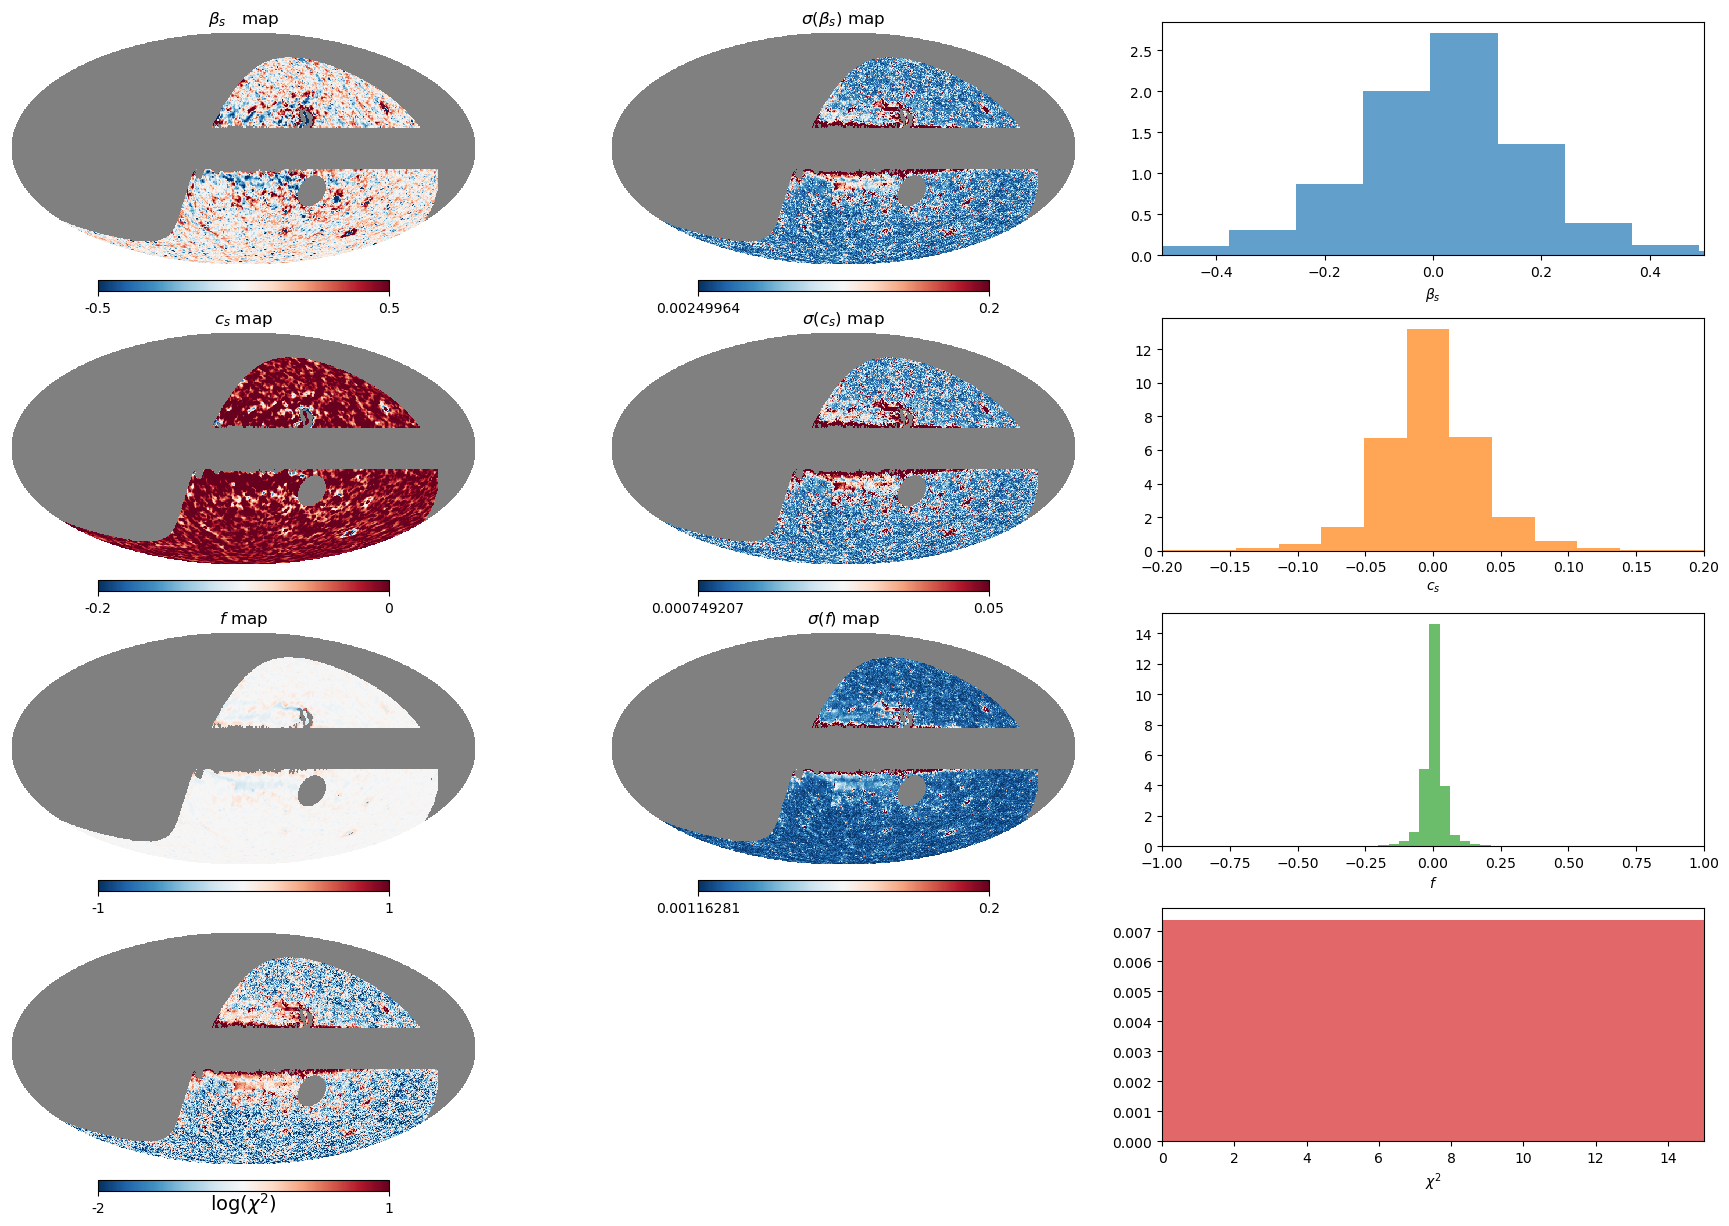

In [16]:
fig, axes = pl.subplots(4, 3, figsize=(18, 12))

# 1st row: betamap
hp.mollview(betamap - mean_beta, sub=(4, 3, 1), min=-0.5, max=0.5,  cmap='RdBu_r',  notext=True,  title=r'$\beta_s$   map' )
hp.mollview(error_betamap, sub=(4, 3, 2), max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(\beta_s)$ map')
axes[0, 2].hist(betamap[~np.isnan(betamap)] - mean_beta, bins=50, density=True, color='C0', alpha=0.7)
axes[0, 2].set_xlabel(r'$\beta_s$')
axes[0, 2].set_xlim( [-0.5, 0.5])
#axes[0, 2].set_ylabel('Density')

# 2nd row: csmap

hp.mollview(csmap, sub=(4, 3, 4), min=-0.2, max=0.,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$c_s$ map')

hp.mollview(error_csmap, sub=(4, 3, 5), max=0.05,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(c_s)$ map')

axes[1, 2].hist(csmap[~np.isnan(csmap)], bins=50, density=True, color='C1', alpha=0.7)
axes[1, 2].set_xlabel(r'$c_s$')
axes[1, 2].set_xlim( [-.2, .2 ])
#axes[1, 2].set_ylabel('Density')

# 3rd row: fmap
hp.mollview(fmap, sub=(4, 3, 7),  cmap='RdBu_r',min=-1,max=1,  notext=True, fig=fig, title=r'$f$ map')
hp.mollview(error_fmap, sub=(4, 3, 8), max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(f)$ map')

axes[2, 2].hist(fmap[~np.isnan(fmap)], bins=50, density=True, color='C2', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[2, 2].set_xlabel(r'$f$')
axes[2, 2].set_xlim( [-1, 1 ])

hp.mollview(np.log10(chisquare_map)   , sub=(4,3,10) ,  min=-2 ,max=1,    unit=r'$\log (\chi^2)$',cmap='RdBu_r',notext=True , title=' ' ) 
axes[3, 2].hist(chisquare_map[~np.isnan(chisquare_map)], bins=50, density=True, color='C3', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[3, 2].set_xlabel( r'$ \chi^2$')
axes[3, 2].set_xlim( [0,15 ])
# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()

In [21]:
import os 

output_dir = "../outputs"


os.makedirs(output_dir, exist_ok=True)

# Save all maps into a single HEALPix FITS file
hp.write_map(
    f"{output_dir}/bfit_maps_south_finest.fits",
    [betamap, csmap, fmap, error_betamap , error_csmap, error_fmap , chisquare_map ],
    column_names=["BETAMAP", "CSMAP", "FMAP","BETAMAP_ERR", "CSMAP_ERR", "FMAP_ERR" ,"CHISQUARE"  ],
    overwrite=True,
    dtype=np.float32
)



In [22]:
# Save the common_footprint mask as a HEALPix FITS file
hp.write_map(
    f"{output_dir}/common_mask_finest_south.fits",
    common_footprint.astype(np.float32),
    overwrite=True,
    dtype=np.float32
)